In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import time
import yaml

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

sys.path.insert(0, '../')

from src.preprocessing import load_arrays
from src.tf_dataset_loader import create_tf_dataset


**Load models**

In [4]:
from src.custom_cells import CustomRNNCell, CustomLSTMCell

custom_objects = {
    'CustomRNNCell': CustomRNNCell,
    'CustomLSTMCell': CustomLSTMCell,
}

rnn_model=tf.keras.models.load_model('../models/rnn_model.keras',custom_objects=custom_objects)
lstm_model=tf.keras.models.load_model('../models/lstm_model.keras',custom_objects=custom_objects)

In [5]:
rnn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn (RNN)                       │ (None, 60, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_1 (RNN)                     │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,621 (92.27 KB)

 Trainable params: 7,873 (30.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 15,748 (61.52 KB)

In [6]:
lstm_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 60, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_2 (RNN)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_3 (RNN)                     │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,573 (349.90 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 59,716 (233.27 KB)

**Load and create test set**

In [7]:
_,_,X_test,_,_,y_test,scaler=load_arrays('../data/processed')
test_ds=create_tf_dataset(X_test,y_test,shuffle=False)
print(test_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 60, 1), dtype=tf.float64, name=None), TensorSpec(shape=(None, 1), dtype=tf.float64, name=None))>


**Predict on test set**

In [8]:
start_time=time.time()
y_pred_rnn=rnn_model.predict(test_ds,verbose=0)
rnn_predict_time = time.time() - start_time

start_time=time.time()
y_pred_lstm=lstm_model.predict(test_ds,verbose=0)
lstm_predict_time=time.time()-start_time

print(f"RNN prediction time: {rnn_predict_time:.2f}s")
print(f"LSTM prediction time: {lstm_predict_time:.2f}s")

RNN prediction time: 1.52s
LSTM prediction time: 1.64s


**Compute metrics**

In [10]:
y_test_original=scaler.inverse_transform(y_test.reshape(-1,1)).flatten()
y_pred_rnn_original = scaler.inverse_transform(y_pred_rnn.reshape(-1, 1)).flatten()
y_pred_lstm_original = scaler.inverse_transform(y_pred_lstm.reshape(-1, 1)).flatten()

rnn_mae=mean_absolute_error(y_test_original,y_pred_rnn_original)
rnn_rmse=np.sqrt(mean_squared_error(y_test_original,y_pred_rnn_original))
rnn_mape=np.mean(np.abs((y_test_original-y_pred_rnn_original)/y_test_original))*100

lstm_mae=mean_absolute_error(y_test_original,y_pred_lstm_original)
lstm_rmse=np.sqrt(mean_squared_error(y_test_original,y_pred_lstm_original))
lstm_mape = np.mean(np.abs((y_test_original - y_pred_lstm_original) / y_test_original)) * 100

print('\nRNN Results:')
print(f'  MAE:  ${rnn_mae:.2f}')
print(f'  RMSE: ${rnn_rmse:.2f}')
print(f"  MAPE: {rnn_mape:.2f}%")

print('\nLSTM Results:')
print(f'  MAE:  ${lstm_mae:.2f}')
print(f'  RMSE: ${lstm_rmse:.2f}')
print(f"  MAPE: {lstm_mape:.2f}%")



RNN Results:
  MAE:  $5597.97
  RMSE: $7571.66
  MAPE: 6.95%

LSTM Results:
  MAE:  $6615.25
  RMSE: $7580.31
  MAPE: 9.18%


In [11]:
comparison_df=pd.DataFrame({
    'Metric':['MAE ($)', 'RMSE ($)','MAPE (%)','Prediction Time(s)'],
    'RNN':[rnn_mae,rnn_rmse,rnn_mape,rnn_predict_time],
    'LSTM':[lstm_mae,lstm_rmse,lstm_mape,lstm_predict_time]
})

comparison_df

,Metric,RNN,LSTM
0,MAE ($),5597.973734,6615.247630
1,RMSE ($),7571.659923,7580.310261
2,MAPE (%),6.947807,9.176983
3,Prediction Time(s),1.521143,1.641501


**Save metrics**

In [12]:
results_dir = '../results/model_comparison/'
os.makedirs(results_dir,exist_ok=True)
comparison_df.to_csv(f"{results_dir}comparison_metrics.csv",index=False)

In [13]:
with open(os.path.join(results_dir, 'comparison_report.txt'), 'w') as f:
    f.write("BITCOIN PRICE FORECASTING: MODEL RELOAD COMPARISON\n")
    f.write("RNN Results:\n")
    f.write(f"  MAE:  ${rnn_mae:.2f}\n")
    f.write(f"  RMSE: ${rnn_rmse:.2f}\n")
    f.write(f"  MAPE: {rnn_mape:.2f}%\n")
    f.write(f"  Prediction Time: {rnn_predict_time:.2f}s\n\n")
    f.write("LSTM Results:\n")
    f.write(f"  MAE:  ${lstm_mae:.2f}\n")
    f.write(f"  RMSE: ${lstm_rmse:.2f}\n")
    f.write(f"  MAPE: {lstm_mape:.2f}%\n")
    f.write(f"  Prediction Time: {lstm_predict_time:.2f}s\n\n")
    f.write("Conclusion:\n")
    winner = "RNN" if rnn_mae < lstm_mae else "LSTM"
    f.write(f"  Better model by MAE: {winner}\n")

**Plot predictions comparison**

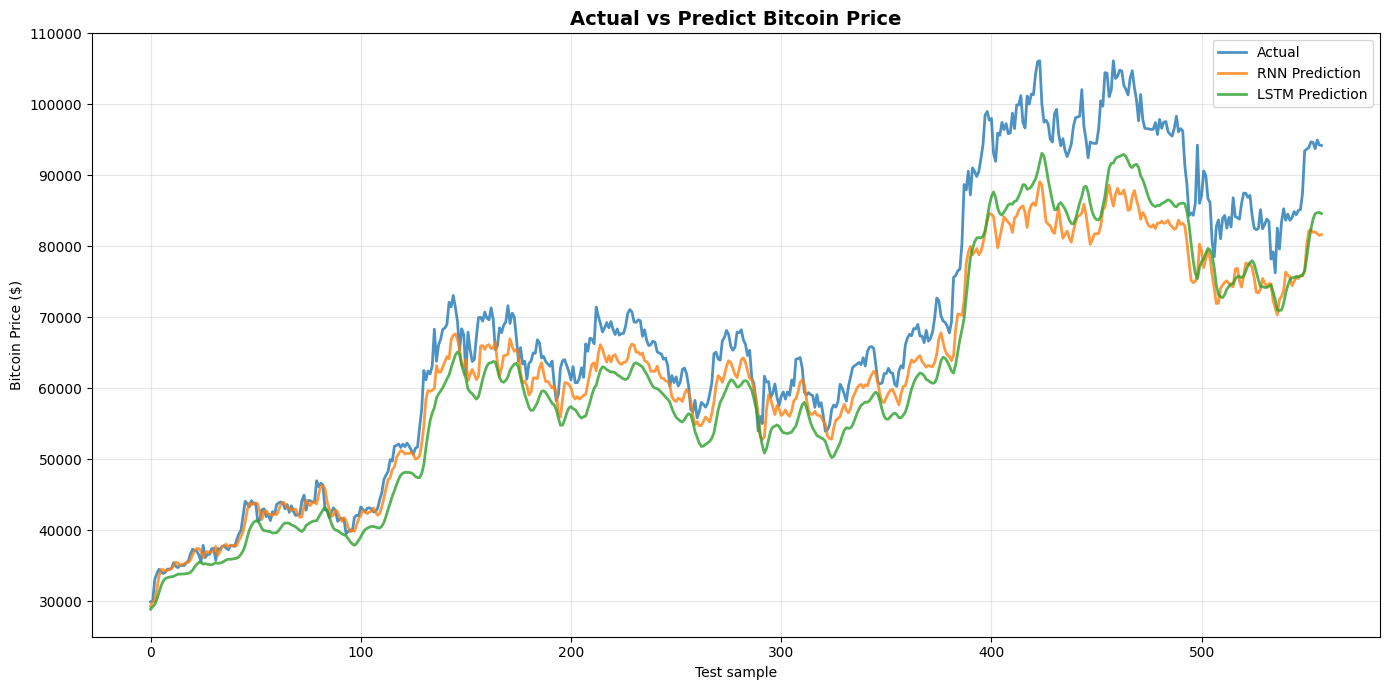

In [15]:
plt.figure(figsize=(14,7))

plt.plot(y_test_original,label='Actual',linewidth=2,alpha=0.8)
plt.plot(y_pred_rnn_original,label='RNN Prediction',linewidth=2,alpha=0.8)
plt.plot(y_pred_lstm_original,label='LSTM Prediction',linewidth=2,alpha=0.8)

plt.title('Actual vs Predict Bitcoin Price',fontsize=14,fontweight='bold')
plt.xlabel('Test sample')
plt.ylabel('Bitcoin Price ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(f'{results_dir}predictions_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


**Plot residuals**

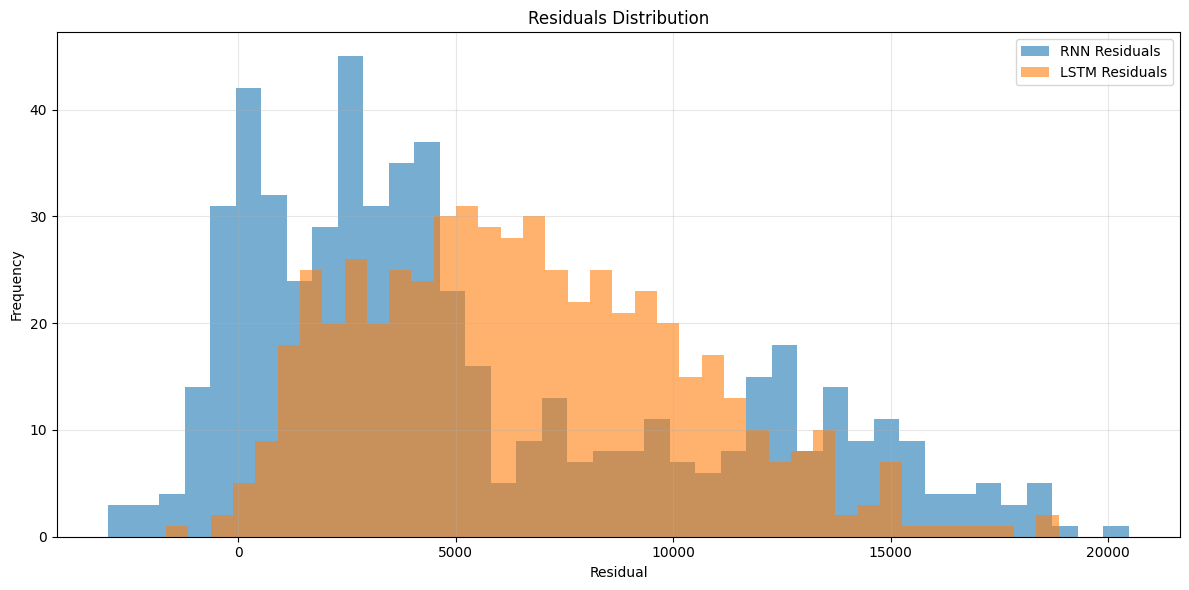

In [16]:
rnn_residuals=y_test_original-y_pred_rnn_original
lstm_residuals=y_test_original-y_pred_lstm_original

plt.figure(figsize=(12,6))
plt.hist(rnn_residuals,bins=40,alpha=0.6,label='RNN Residuals')
plt.hist(lstm_residuals,bins=40,alpha=0.6,label='LSTM Residuals')
plt.title('Residuals Distribution')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(f"{results_dir}residuals_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

**Save detailed predictions**

In [17]:
predictions_df = pd.DataFrame({
    'Actual': y_test_original,
    'RNN_Prediction': y_pred_rnn_original,
    'LSTM_Prediction': y_pred_lstm_original,
    'RNN_Residual': rnn_residuals,
    'LSTM_Residual': lstm_residuals
})

predictions_df.to_csv(f"{results_dir}'predictions_detailed.csv", index=False)
print(predictions_df.head())

         Actual  RNN_Prediction  LSTM_Prediction  RNN_Residual  LSTM_Residual
0  29918.412109    29297.669922     28867.681641    620.742188    1050.730469
1  29993.896484    29904.351562     29228.535156     89.544922     765.361328
2  33086.234375    30085.054688     29532.347656   3001.179688    3553.886719
3  33901.527344    31692.291016     30267.906250   2209.236328    3633.621094
4  34502.820312    33533.308594     31211.791016    969.511719    3291.029297
